In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
experiment_dir = Path("results/47V/experiments/mlp_window_grid")
experiment_dir.resolve()
mlp_trials = pd.read_csv(experiment_dir / "mlp_trials.csv")
mlp_summary = pd.read_csv(experiment_dir / "mlp_configuration_summary.csv")
std_summary = pd.read_csv(experiment_dir / "standard_method_summary.csv")

manifest_path = experiment_dir / "experiment_manifest.json"
manifest = json.loads(manifest_path.read_text(encoding="utf-8")) if manifest_path.exists() else {}

print("mlp_trials:", mlp_trials.shape)
print("mlp_summary:", mlp_summary.shape)
print("std_summary:", std_summary.shape)

mlp_trials: (27, 16)
mlp_summary: (1, 16)
std_summary: (27, 16)


In [3]:
window_rows = []

datasets_dir = experiment_dir / "datasets"
for wdir in sorted(datasets_dir.glob("window_*")):
    manifest_path = wdir / "manifest.json"
    if not manifest_path.exists():
        continue
    m = json.loads(manifest_path.read_text(encoding="utf-8"))
    derived = m.get("derived_window", {})
    window_id = int(wdir.name.split("_")[-1])
    before_ns = derived.get("window_before_ns")
    after_ns = derived.get("window_after_ns")
    window_rows.append(
        {
            "window_id": window_id,
            "window_before_ns": before_ns,
            "window_after_ns": after_ns,
            "window_width_ns": None if before_ns is None or after_ns is None else before_ns + after_ns,
            "input_length": m.get("input_length"),
        }
    )

window_df = pd.DataFrame(window_rows).sort_values("window_id")
display(window_df)

KeyError: 'window_id'

In [ ]:
std_summary2 = std_summary.merge(window_df, on="window_id", how="left")
display(std_summary2.head())

,method_code,window_id,config_id,completed_runs,completed_folds,mean_validation_rmse,std_validation_rmse,se_validation_rmse,median_validation_rmse,worst_validation_rmse,mean_validation_bias,mean_abs_validation_bias,mean_validation_ctr,std_validation_ctr,mean_runtime_seconds,selected,window_before_ns,window_after_ns,window_width_ns,input_length
0,0,1,0,1,1,95.544238,0.0,0.0,95.544238,95.544238,-29.222586,29.222586,204.031821,0.0,0.006999,False,4.0,6.0,10.0,4001
1,1,1,0,1,1,77.969787,0.0,0.0,77.969787,77.969787,2.858427,2.858427,173.531955,0.0,0.007003,False,4.0,6.0,10.0,4001
2,2,1,1,1,1,67.786333,0.0,0.0,67.786333,67.786333,-10.164334,10.164334,146.171466,0.0,0.361996,True,4.0,6.0,10.0,4001
3,0,2,0,1,1,95.544238,0.0,0.0,95.544238,95.544238,-29.222586,29.222586,204.031821,0.0,0.006999,False,4.0,11.0,15.0,1501
4,1,2,0,1,1,77.969787,0.0,0.0,77.969787,77.969787,2.858427,2.858427,173.531955,0.0,0.012000,False,4.0,11.0,15.0,1501


In [ ]:
method_map = {0: "LED", 1: "CFD", 2: "linear_spline"}

if "method_code" in std_summary2.columns:
    std_summary2["method_name"] = std_summary2["method_code"].map(method_map)

display(std_summary2[["method_code", "method_name", "window_id", "window_before_ns", "window_after_ns"]].head())

,method_code,method_name,window_id,window_before_ns,window_after_ns
0,0,LED,1,4.0,6.0
1,1,CFD,1,4.0,6.0
2,2,linear_spline,1,4.0,6.0
3,0,LED,2,4.0,11.0
4,1,CFD,2,4.0,11.0


In [ ]:
std_best_by_window = (
    std_summary2.sort_values("mean_validation_rmse")
    .groupby("window_id", as_index=False)
    .first()
    .sort_values("window_width_ns")
)

display(std_best_by_window[[
    "window_id",
    "window_before_ns",
    "window_after_ns",
    "window_width_ns",
    "method_name",
    "mean_validation_rmse",
    "mean_validation_bias",
    "mean_validation_ctr",
]])

,window_id,window_before_ns,window_after_ns,window_width_ns,method_name,mean_validation_rmse,mean_validation_bias,mean_validation_ctr
0,1,4.0,6.0,10.0,linear_spline,67.786333,-10.164334,146.171466
1,2,4.0,11.0,15.0,linear_spline,69.330618,-6.024967,150.297179
2,3,4.0,16.0,20.0,linear_spline,71.459860,-3.689595,159.209125
3,4,4.0,21.0,25.0,linear_spline,71.050267,-2.112456,160.029733
4,5,4.0,26.0,30.0,linear_spline,75.763372,-3.296382,170.573205
5,6,4.0,31.0,35.0,linear_spline,73.584908,-3.104134,169.046672
6,7,4.0,36.0,40.0,linear_spline,74.372621,-1.683084,165.944125
7,8,4.0,41.0,45.0,linear_spline,77.589785,-1.353517,166.925475
8,9,4.0,50.0,54.0,linear_spline,77.619030,0.551562,180.130256


In [ ]:
selected_rows = mlp_summary[mlp_summary.get("selected", False) == True]
display(selected_rows)

,config_id,completed_runs,completed_folds,mean_validation_rmse,std_validation_rmse,se_validation_rmse,median_validation_rmse,worst_validation_rmse,mean_validation_bias,mean_abs_validation_bias,mean_validation_ctr,std_validation_ctr,mean_runtime_seconds,required_runs,selected,rank
0,mlp_001,27,27,66.581068,0.766212,0.147458,66.835368,67.227023,-1.195441,3.077455,146.317659,4.895389,34.472389,3,True,1


In [ ]:
def extract_window_id(trial_id: str) -> int:
    parts = str(trial_id).split("__")
    for p in parts:
        if p.startswith("w"):
            try:
                return int(p[1:])
            except ValueError:
                pass
    return np.nan

mlp_trials2 = mlp_trials.copy()
mlp_trials2["window_id"] = mlp_trials2["trial_id"].map(extract_window_id)
mlp_trials2 = mlp_trials2.merge(window_df, on="window_id", how="left")

display(mlp_trials2.head())

,trial_id,config_id,fold,seed,status_code,train_n,validation_n,best_epoch,train_rmse,validation_rmse,...,validation_bias,validation_loss,validation_ctr,validation_ctr_error,runtime_seconds,window_id,window_before_ns,window_after_ns,window_width_ns,input_length
0,mlp__w1__f0__s101____15f13126,mlp_001,0,101,1,2167,457,85,64.508187,66.612854,...,-7.200021,4437.272305,139.983141,NaN,34.975393,1,4.0,6.0,10.0,4001
1,mlp__w1__f0__s202____b8aec7a8,mlp_001,0,202,1,2167,457,74,64.690326,66.588235,...,-6.771807,4433.993021,140.620179,NaN,33.136794,1,4.0,6.0,10.0,4001
2,mlp__w1__f0__s303____56184155,mlp_001,0,303,1,2167,457,80,64.447032,66.571176,...,-6.188319,4431.721420,137.843933,NaN,34.358358,1,4.0,6.0,10.0,4001
3,mlp__w2__f0__s101____f44af1e2,mlp_001,0,101,1,2167,457,35,64.667137,66.829636,...,-5.937421,4466.200242,143.622062,NaN,29.702290,2,4.0,11.0,15.0,1501
4,mlp__w2__f0__s202____4f7797aa,mlp_001,0,202,1,2167,457,32,64.555112,66.926261,...,-3.624839,4479.124400,144.457808,NaN,27.909987,2,4.0,11.0,15.0,1501


In [ ]:
mlp_by_window_config = (
    mlp_trials2[mlp_trials2["status_code"] == 1]
    .groupby(["window_id", "config_id"], as_index=False)
    .agg(
        mean_validation_rmse=("validation_rmse", "mean"),
        mean_validation_bias=("validation_bias", "mean"),
        mean_validation_ctr=("validation_ctr", "mean"),
        mean_best_epoch=("best_epoch", "mean"),
        runs=("trial_id", "count"),
        window_before_ns=("window_before_ns", "first"),
        window_after_ns=("window_after_ns", "first"),
        window_width_ns=("window_width_ns", "first"),
    )
)

mlp_best_by_window = (
    mlp_by_window_config.sort_values("mean_validation_rmse")
    .groupby("window_id", as_index=False)
    .first()
    .sort_values("window_width_ns")
)

display(mlp_best_by_window)

,window_id,config_id,mean_validation_rmse,mean_validation_bias,mean_validation_ctr,mean_best_epoch,runs,window_before_ns,window_after_ns,window_width_ns
0,1,mlp_001,66.590755,-6.720049,139.482418,79.666667,3,4.0,6.0,10.0
1,2,mlp_001,66.924775,-4.531961,145.915732,33.666667,3,4.0,11.0,15.0
2,3,mlp_001,67.066356,-2.125049,144.000778,51.000000,3,4.0,16.0,20.0
3,4,mlp_001,67.166708,2.786939,151.005989,66.000000,3,4.0,21.0,25.0
4,5,mlp_001,66.858887,1.514300,151.491675,75.000000,3,4.0,26.0,30.0
5,6,mlp_001,66.796677,-0.574252,151.257062,61.333333,3,4.0,31.0,35.0
6,7,mlp_001,66.850059,-2.114567,148.486694,46.333333,3,4.0,36.0,40.0
7,8,mlp_001,66.480373,1.871301,145.700203,65.333333,3,4.0,41.0,45.0
8,9,mlp_001,64.495021,-0.865627,139.518376,60.666667,3,4.0,50.0,54.0


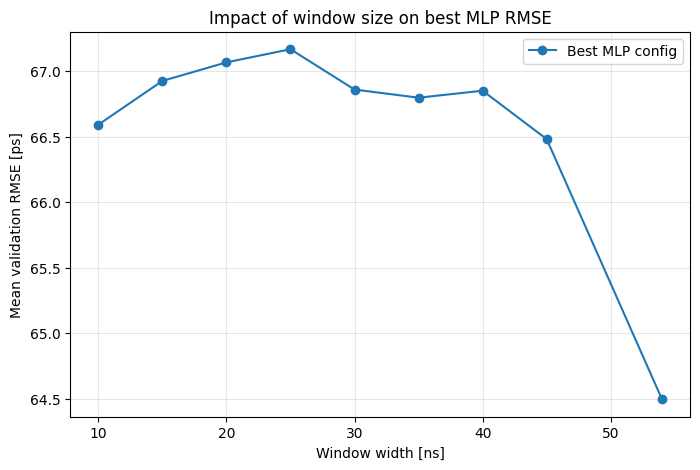

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(
    mlp_best_by_window["window_width_ns"],
    mlp_best_by_window["mean_validation_rmse"],
    marker="o",
    label="Best MLP config",
)
plt.xlabel("Window width [ns]")
plt.ylabel("Mean validation RMSE [ps]")
plt.title("Impact of window size on best MLP RMSE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
compare = mlp_best_by_window.merge(
    std_best_by_window[["window_id", "window_width_ns", "mean_validation_rmse", "method_name"]],
    on=["window_id", "window_width_ns"],
    suffixes=("_mlp", "_std"),
)

display(compare[[
    "window_id",
    "window_width_ns",
    "config_id",
    "mean_validation_rmse_mlp",
    "method_name",
    "mean_validation_rmse_std",
]])

,window_id,window_width_ns,config_id,mean_validation_rmse_mlp,method_name,mean_validation_rmse_std
0,1,10.0,mlp_001,66.590755,linear_spline,67.786333
1,2,15.0,mlp_001,66.924775,linear_spline,69.330618
2,3,20.0,mlp_001,67.066356,linear_spline,71.459860
3,4,25.0,mlp_001,67.166708,linear_spline,71.050267
4,5,30.0,mlp_001,66.858887,linear_spline,75.763372
5,6,35.0,mlp_001,66.796677,linear_spline,73.584908
6,7,40.0,mlp_001,66.850059,linear_spline,74.372621
7,8,45.0,mlp_001,66.480373,linear_spline,77.589785
8,9,54.0,mlp_001,64.495021,linear_spline,77.619030


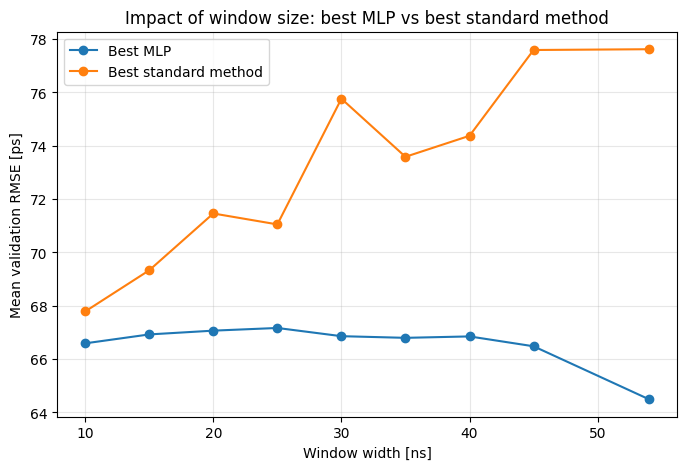

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(
    compare["window_width_ns"],
    compare["mean_validation_rmse_mlp"],
    marker="o",
    label="Best MLP",
)
plt.plot(
    compare["window_width_ns"],
    compare["mean_validation_rmse_std"],
    marker="o",
    label="Best standard method",
)
plt.xlabel("Window width [ns]")
plt.ylabel("Mean validation RMSE [ps]")
plt.title("Impact of window size: best MLP vs best standard method")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

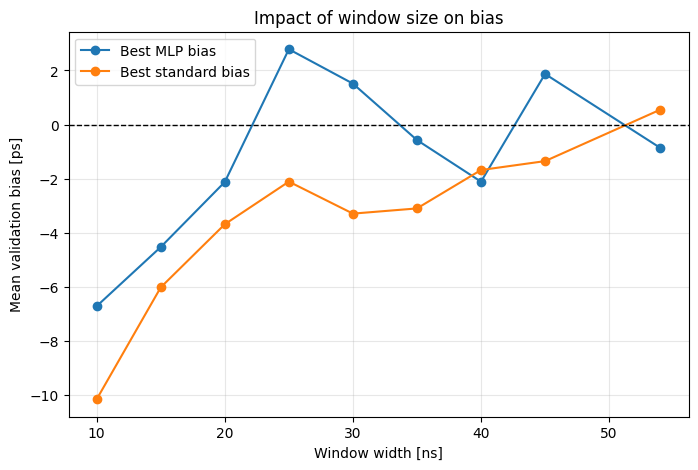

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(
    mlp_best_by_window["window_width_ns"],
    mlp_best_by_window["mean_validation_bias"],
    marker="o",
    label="Best MLP bias",
)
plt.plot(
    std_best_by_window["window_width_ns"],
    std_best_by_window["mean_validation_bias"],
    marker="o",
    label="Best standard bias",
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Window width [ns]")
plt.ylabel("Mean validation bias [ps]")
plt.title("Impact of window size on bias")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
winner_configs = mlp_best_by_window[["window_id", "config_id", "window_width_ns"]].copy()
display(winner_configs.sort_values("window_width_ns"))

,window_id,config_id,window_width_ns
0,1,mlp_001,10.0
1,2,mlp_001,15.0
2,3,mlp_001,20.0
3,4,mlp_001,25.0
4,5,mlp_001,30.0
5,6,mlp_001,35.0
6,7,mlp_001,40.0
7,8,mlp_001,45.0
8,9,mlp_001,54.0


In [ ]:
summary_table = compare.merge(
    mlp_best_by_window[["window_id", "mean_validation_bias", "mean_validation_ctr"]],
    on="window_id",
    how="left",
).rename(
    columns={
        "config_id": "best_mlp_config",
        "mean_validation_rmse_mlp": "best_mlp_rmse_ps",
        "mean_validation_rmse_std": "best_std_rmse_ps",
        "method_name": "best_std_method",
        "mean_validation_bias": "best_mlp_bias_ps",
        "mean_validation_ctr": "best_mlp_ctr_ps",
    }
)

display(summary_table.sort_values("window_width_ns"))

,window_id,best_mlp_config,best_mlp_rmse_ps,mean_validation_bias_x,mean_validation_ctr_x,mean_best_epoch,runs,window_before_ns,window_after_ns,window_width_ns,best_std_rmse_ps,best_std_method,mean_validation_bias_y,mean_validation_ctr_y
0,1,mlp_001,66.590755,-6.720049,139.482418,79.666667,3,4.0,6.0,10.0,67.786333,linear_spline,-6.720049,139.482418
1,2,mlp_001,66.924775,-4.531961,145.915732,33.666667,3,4.0,11.0,15.0,69.330618,linear_spline,-4.531961,145.915732
2,3,mlp_001,67.066356,-2.125049,144.000778,51.000000,3,4.0,16.0,20.0,71.459860,linear_spline,-2.125049,144.000778
3,4,mlp_001,67.166708,2.786939,151.005989,66.000000,3,4.0,21.0,25.0,71.050267,linear_spline,2.786939,151.005989
4,5,mlp_001,66.858887,1.514300,151.491675,75.000000,3,4.0,26.0,30.0,75.763372,linear_spline,1.514300,151.491675
5,6,mlp_001,66.796677,-0.574252,151.257062,61.333333,3,4.0,31.0,35.0,73.584908,linear_spline,-0.574252,151.257062
6,7,mlp_001,66.850059,-2.114567,148.486694,46.333333,3,4.0,36.0,40.0,74.372621,linear_spline,-2.114567,148.486694
7,8,mlp_001,66.480373,1.871301,145.700203,65.333333,3,4.0,41.0,45.0,77.589785,linear_spline,1.871301,145.700203
8,9,mlp_001,64.495021,-0.865627,139.518376,60.666667,3,4.0,50.0,54.0,77.619030,linear_spline,-0.865627,139.518376


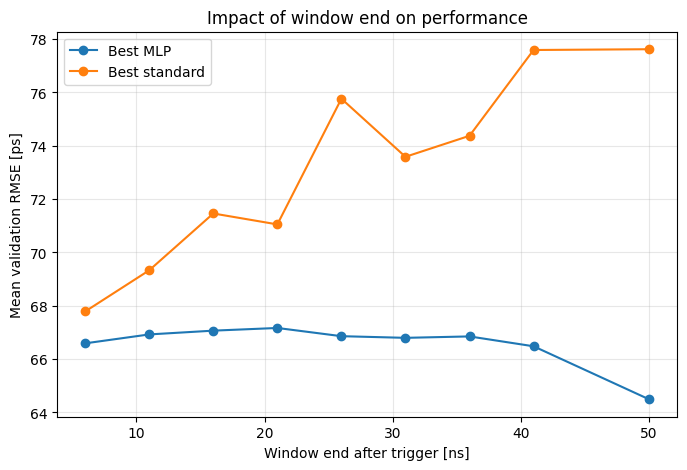

In [ ]:
compare2 = mlp_best_by_window.merge(
    std_best_by_window[["window_id", "window_after_ns", "mean_validation_rmse", "method_name"]],
    on=["window_id", "window_after_ns"],
    suffixes=("_mlp", "_std"),
)

plt.figure(figsize=(8, 5))
plt.plot(compare2["window_after_ns"], compare2["mean_validation_rmse_mlp"], marker="o", label="Best MLP")
plt.plot(compare2["window_after_ns"], compare2["mean_validation_rmse_std"], marker="o", label="Best standard")
plt.xlabel("Window end after trigger [ns]")
plt.ylabel("Mean validation RMSE [ps]")
plt.title("Impact of window end on performance")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

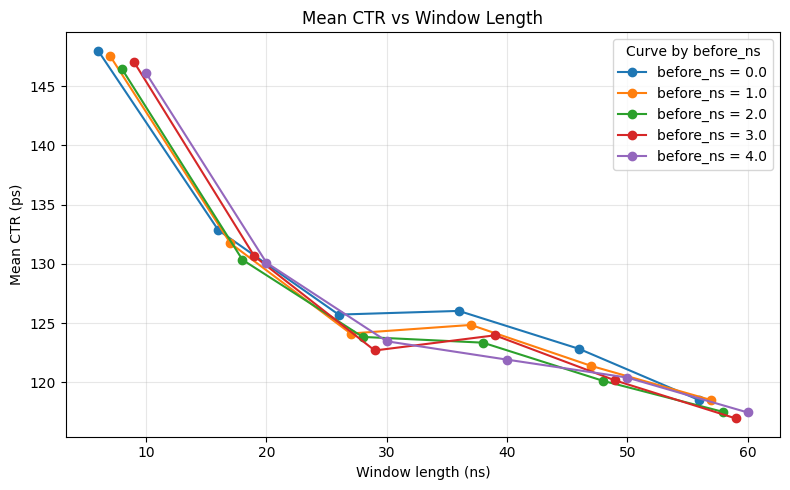

In [7]:
# Load data
window_df =  pd.read_csv("results/all/experiments/mlp_window_grid_diff/windows.csv")
summary_df =  pd.read_csv("results/all/experiments/mlp_window_grid_diff/summary.csv")

# Merge on window_id
df = summary_df.merge(window_df, on="window_id", how="left")

# Compute window length
df["window_length_ns"] = df["before_ns"] + df["after_ns"]

# Optional: keep only completed entries
if "complete" in df.columns:
    df = df[df["complete"] == 1]

# Plot mean CTR vs window length, grouped by before_ns
plt.figure(figsize=(8, 5))

for before_ns, group in sorted(df.groupby("before_ns")):
    group = group.sort_values("window_length_ns")
    plt.plot(
        group["window_length_ns"],
        group["mean_validation_ctr_ps"],
        marker="o",
        label=f"before_ns = {before_ns}"
    )

plt.xlabel("Window length (ns)")
plt.ylabel("Mean CTR (ps)")
plt.title("Mean CTR vs Window Length")
plt.legend(title="Curve by before_ns")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

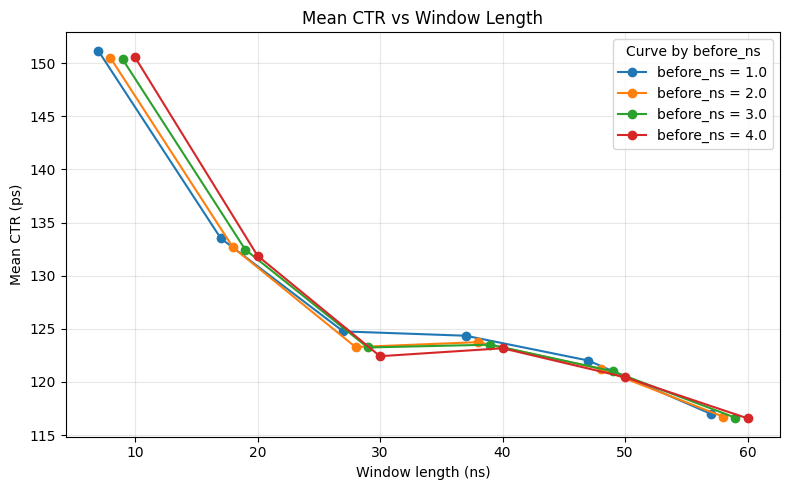

In [8]:
# Load data
window_df =  pd.read_csv("results/all/experiments/linear_svr_window_grid_epsilon_50/windows.csv")
summary_df =  pd.read_csv("results/all/experiments/linear_svr_window_grid_epsilon_50/summary.csv")

# Merge on window_id
df = summary_df.merge(window_df, on="window_id", how="left")

# Compute window length
df["window_length_ns"] = df["before_ns"] + df["after_ns"]

# Optional: keep only completed entries
if "complete" in df.columns:
    df = df[df["complete"] == 1]

# Plot mean CTR vs window length, grouped by before_ns
plt.figure(figsize=(8, 5))

for before_ns, group in sorted(df.groupby("before_ns")):
    group = group.sort_values("window_length_ns")
    plt.plot(
        group["window_length_ns"],
        group["mean_validation_ctr_ps"],
        marker="o",
        label=f"before_ns = {before_ns}"
    )

plt.xlabel("Window length (ns)")
plt.ylabel("Mean CTR (ps)")
plt.title("Mean CTR vs Window Length")
plt.legend(title="Curve by before_ns")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

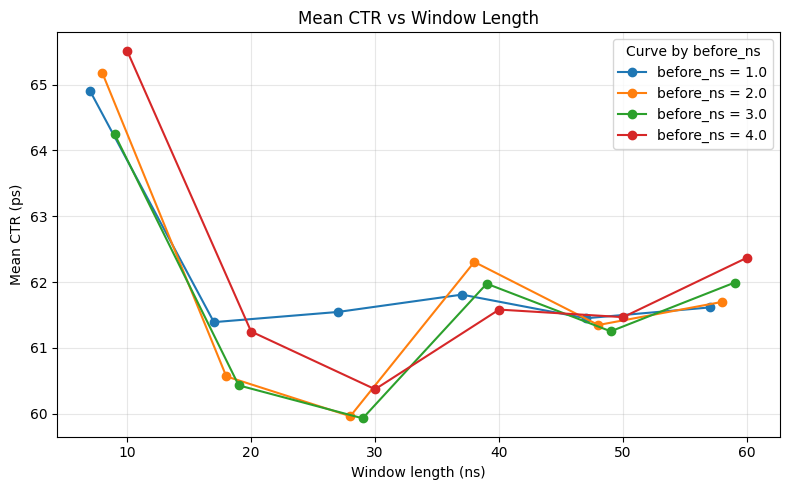

In [3]:
# Load data
window_df =  pd.read_csv("results/47V/experiments/svr_window_grid_timing_led/windows.csv")
summary_df =  pd.read_csv("results/47V/experiments/svr_window_grid_timing_led/summary.csv")

# Merge on window_id
df = summary_df.merge(window_df, on="window_id", how="left")

# Compute window length
df["window_length_ns"] = df["before_ns"] + df["after_ns"]

# Optional: keep only completed entries
if "complete" in df.columns:
    df = df[df["complete"] == 1]

# Plot mean CTR vs window length, grouped by before_ns
plt.figure(figsize=(8, 5))

for before_ns, group in sorted(df.groupby("before_ns")):
    group = group.sort_values("window_length_ns")
    plt.plot(
        group["window_length_ns"],
        group["mean_validation_ctr_ps"],
        marker="o",
        label=f"before_ns = {before_ns}"
    )

plt.xlabel("Window length (ns)")
plt.ylabel("Mean CTR (ps)")
plt.title("Mean CTR vs Window Length")
plt.legend(title="Curve by before_ns")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

CV-selected best loss for every file, channel mode and model


,file_name,voltage_V,channel_mode,model_id,loss_id,input_transform,window_start_ns,window_end_ns,window_size_ns,validation_ctr_mean_ps,validation_ctr_sem_ps,blind_ctr_mean_ps,blind_ctr_sem_ps,blind_minus_validation_ps,relative_generalization_gap_pct,compatibility_z,compatibility_class
0,45V-400mV.root,45.0,energy_to_energy,linear_svr,mse,normalize,-6.0,10.0,16.0,139.316,1.439,144.211,1.325,4.895,3.513,2.503,"small practical gap, SEM mismatch"
1,46V-440mV.root,46.0,energy_to_energy,linear_svr,mse,differentiate,-4.0,10.0,14.0,137.091,1.378,127.718,0.368,-9.373,-6.837,-6.574,strong mismatch
2,47V-470mV.root,47.0,energy_to_energy,linear_svr,mse,normalize,-4.0,10.0,14.0,129.774,1.480,135.435,0.445,5.661,4.362,3.663,"small practical gap, SEM mismatch"
3,48V-480mV.root,48.0,energy_to_energy,linear_svr,mse,normalize,-4.0,10.0,14.0,125.284,1.147,124.152,0.410,-1.132,-0.903,-0.929,compatible
4,49V-490mV.root,49.0,energy_to_energy,linear_svr,mse,normalize,-6.0,10.0,16.0,122.299,0.623,121.309,1.002,-0.990,-0.810,-0.839,compatible
5,45V-400mV.root,45.0,energy_to_timing,linear_svr,mse,differentiate,-4.0,10.0,14.0,75.045,2.309,72.790,0.537,-2.256,-3.006,-0.951,compatible
6,46V-440mV.root,46.0,energy_to_timing,linear_svr,mse,differentiate,-4.0,10.0,14.0,74.118,0.527,73.151,0.349,-0.967,-1.305,-1.530,compatible
7,47V-470mV.root,47.0,energy_to_timing,linear_svr,mse,differentiate,-4.0,10.0,14.0,72.594,0.600,74.782,0.331,2.188,3.014,3.191,"small practical gap, SEM mismatch"
8,48V-480mV.root,48.0,energy_to_timing,linear_svr,mse,normalize,-4.0,10.0,14.0,72.788,1.249,71.889,0.926,-0.898,-1.234,-0.578,compatible
9,49V-490mV.root,49.0,energy_to_timing,linear_svr,mse,normalize,-2.0,10.0,12.0,72.650,1.073,76.683,0.271,4.033,5.551,3.644,strong mismatch



Loss-function summary


,model_id,channel_mode,loss_id,n_cv_selections,validation_ctr_median_ps,blind_ctr_median_ps,median_blind_minus_validation_ps,median_absolute_relative_gap_pct,statistical_compatibility_rate_pct,practical_compatibility_rate_pct
0,linear_svr,energy_to_energy,mse,5,129.774,127.718,-0.990,3.513,40.0,80.0
1,linear_svr,energy_to_timing,mse,5,72.788,73.151,-0.898,3.006,60.0,80.0
2,linear_svr,timing_to_timing,mse,5,58.788,58.894,-0.725,1.281,80.0,100.0



Selected-window summary


,model_id,channel_mode,window_start_ns,window_end_ns,window_size_ns,n_cv_selections,validation_ctr_median_ps,blind_ctr_median_ps,median_generalization_gap_ps,practical_compatibility_rate_pct
1,linear_svr,energy_to_energy,-4.0,10.0,14.0,3,129.774,127.718,-1.132,66.667
0,linear_svr,energy_to_energy,-6.0,10.0,16.0,2,130.808,132.760,1.952,100.000
2,linear_svr,energy_to_timing,-4.0,10.0,14.0,4,73.453,72.970,-0.933,100.000
3,linear_svr,energy_to_timing,-2.0,10.0,12.0,1,72.650,76.683,4.033,0.000
5,linear_svr,timing_to_timing,-2.0,10.0,12.0,4,58.864,59.051,-0.229,100.000
4,linear_svr,timing_to_timing,-4.0,10.0,14.0,1,58.154,57.409,-0.745,100.000



Largest CV-versus-blind discrepancies


,file_name,channel_mode,model_id,loss_id,input_transform,window_start_ns,window_end_ns,validation_ctr_mean_ps,blind_ctr_mean_ps,blind_minus_validation_ps,relative_generalization_gap_pct,compatibility_z,compatibility_class
1,46V-440mV.root,energy_to_energy,linear_svr,mse,differentiate,-4.0,10.0,137.091,127.718,-9.373,-6.837,-6.574,strong mismatch
2,47V-470mV.root,energy_to_energy,linear_svr,mse,normalize,-4.0,10.0,129.774,135.435,5.661,4.362,3.663,"small practical gap, SEM mismatch"
0,45V-400mV.root,energy_to_energy,linear_svr,mse,normalize,-6.0,10.0,139.316,144.211,4.895,3.513,2.503,"small practical gap, SEM mismatch"
9,49V-490mV.root,energy_to_timing,linear_svr,mse,normalize,-2.0,10.0,72.650,76.683,4.033,5.551,3.644,strong mismatch
7,47V-470mV.root,energy_to_timing,linear_svr,mse,differentiate,-4.0,10.0,72.594,74.782,2.188,3.014,3.191,"small practical gap, SEM mismatch"
10,45V-400mV.root,timing_to_timing,linear_svr,mse,normalize,-2.0,10.0,60.907,58.894,-2.012,-3.304,-4.395,"small practical gap, SEM mismatch"


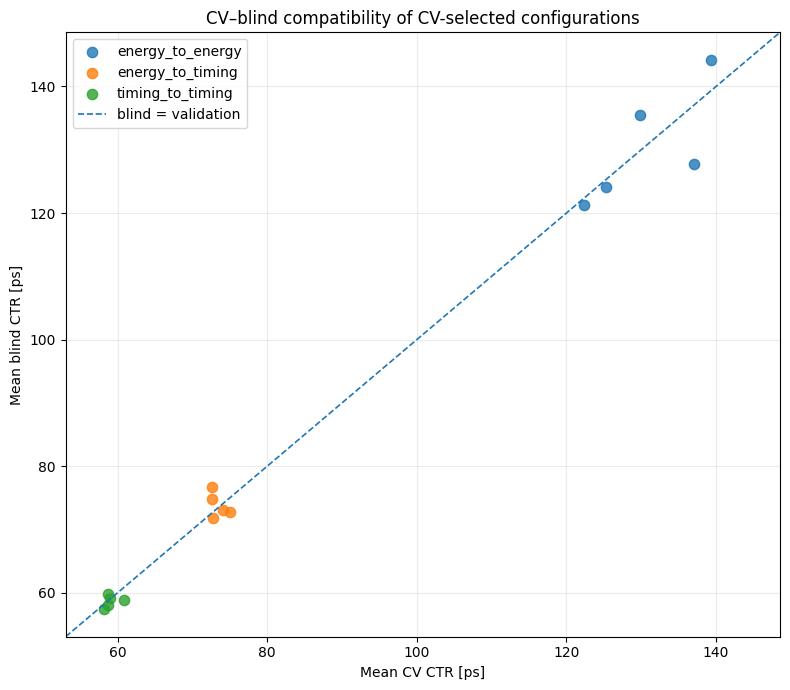

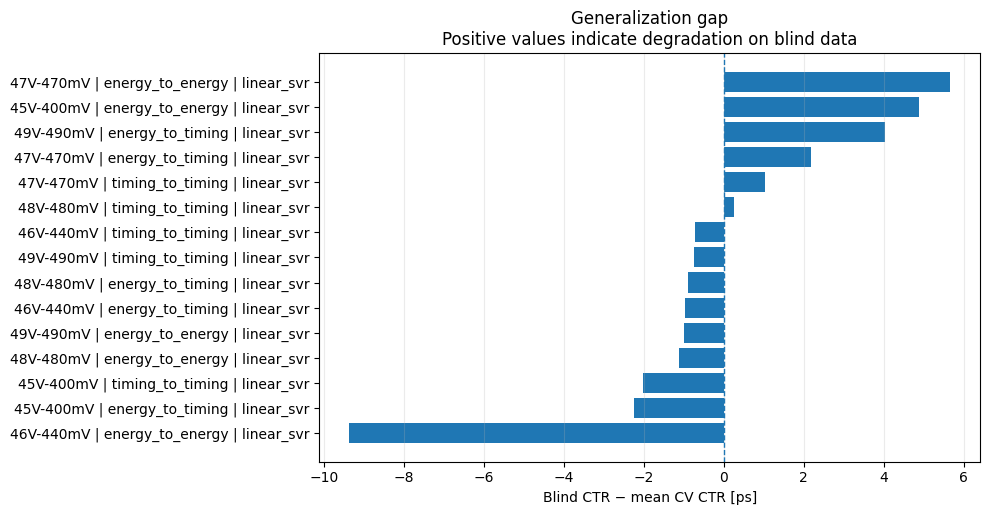

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------

CSV_PATH = Path(
    "results/studies/folder_window_channel_2/summary_results.csv"
)

# Approximate CV-versus-blind compatibility threshold.
# This is a diagnostic, not a rigorous independent-samples hypothesis test,
# because CV folds and fold-trained blind predictions are correlated.
Z_COMPATIBILITY_LIMIT = 1.96

# A second, practical compatibility criterion.
PRACTICAL_GAP_LIMIT_PCT = 5.0


# ---------------------------------------------------------------------
# Load and validate
# ---------------------------------------------------------------------

df = pd.read_csv(CSV_PATH)

required_columns = {
    "file_name",
    "voltage_V",
    "channel_mode",
    "model_id",
    "loss_id",
    "loss_type",
    "input_transform",
    "window_start_ns",
    "window_end_ns",
    "validation_ctr_mean_ps",
    "validation_ctr_sem_ps",
    "blind_ctr_mean_ps",
    "blind_ctr_sem_ps",
}

missing = required_columns.difference(df.columns)

if missing:
    raise ValueError(
        "The CSV is missing required columns:\n"
        + "\n".join(f"- {column}" for column in sorted(missing))
    )

numeric_columns = [
    "voltage_V",
    "window_start_ns",
    "window_end_ns",
    "validation_ctr_mean_ps",
    "validation_ctr_sem_ps",
    "blind_ctr_mean_ps",
    "blind_ctr_sem_ps",
    "validation_relative_improvement_mean_pct",
    "blind_relative_improvement_mean_pct",
]

for column in numeric_columns:
    if column in df.columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

df = df.dropna(
    subset=[
        "validation_ctr_mean_ps",
        "blind_ctr_mean_ps",
        "window_start_ns",
        "window_end_ns",
    ]
).copy()

df["window_size_ns"] = (
    df["window_end_ns"] - df["window_start_ns"]
)


# ---------------------------------------------------------------------
# CV-versus-blind compatibility
# ---------------------------------------------------------------------

df["blind_minus_validation_ps"] = (
    df["blind_ctr_mean_ps"] - df["validation_ctr_mean_ps"]
)

df["absolute_generalization_gap_ps"] = (
    df["blind_minus_validation_ps"].abs()
)

df["relative_generalization_gap_pct"] = (
    100.0
    * df["blind_minus_validation_ps"]
    / df["validation_ctr_mean_ps"]
)

df["combined_ctr_sem_ps"] = np.sqrt(
    df["validation_ctr_sem_ps"].fillna(0.0) ** 2
    + df["blind_ctr_sem_ps"].fillna(0.0) ** 2
)

# Avoid division by zero.
df["compatibility_z"] = np.where(
    df["combined_ctr_sem_ps"] > 0,
    df["blind_minus_validation_ps"] / df["combined_ctr_sem_ps"],
    np.nan,
)

df["statistically_compatible_95pct"] = (
    df["compatibility_z"].abs() <= Z_COMPATIBILITY_LIMIT
)

df["practically_compatible_5pct"] = (
    df["relative_generalization_gap_pct"].abs()
    <= PRACTICAL_GAP_LIMIT_PCT
)

df["compatibility_class"] = np.select(
    [
        df["statistically_compatible_95pct"]
        & df["practically_compatible_5pct"],

        df["practically_compatible_5pct"],

        df["compatibility_z"].abs() <= 3.0,
    ],
    [
        "compatible",
        "small practical gap, SEM mismatch",
        "moderate mismatch",
    ],
    default="strong mismatch",
)


# ---------------------------------------------------------------------
# Select the best loss correctly: CV only
# ---------------------------------------------------------------------
#
# For each file/channel/model:
#     choose the loss having the minimum mean CV CTR.
#
# Blind CTR is deliberately NOT used in this selection.
# ---------------------------------------------------------------------

selection_key = [
    "file_name",
    "channel_mode",
    "model_id",
]

best_loss_indices = (
    df.groupby(selection_key, dropna=False)["validation_ctr_mean_ps"]
    .idxmin()
)

best_loss_rows = (
    df.loc[best_loss_indices]
    .sort_values(
        [
            "model_id",
            "channel_mode",
            "voltage_V",
        ]
    )
    .reset_index(drop=True)
)


print("CV-selected best loss for every file, channel mode and model")

display_columns = [
    "file_name",
    "voltage_V",
    "channel_mode",
    "model_id",
    "loss_id",
    "input_transform",
    "window_start_ns",
    "window_end_ns",
    "window_size_ns",
    "validation_ctr_mean_ps",
    "validation_ctr_sem_ps",
    "blind_ctr_mean_ps",
    "blind_ctr_sem_ps",
    "blind_minus_validation_ps",
    "relative_generalization_gap_pct",
    "compatibility_z",
    "compatibility_class",
]

display(
    best_loss_rows[display_columns].round(3)
)


# ---------------------------------------------------------------------
# Which loss wins most frequently?
# ---------------------------------------------------------------------

loss_summary = (
    best_loss_rows
    .groupby(
        [
            "model_id",
            "channel_mode",
            "loss_id",
            "loss_type",
        ],
        dropna=False,
    )
    .agg(
        n_cv_selections=("file_name", "size"),
        validation_ctr_median_ps=(
            "validation_ctr_mean_ps",
            "median",
        ),
        blind_ctr_median_ps=(
            "blind_ctr_mean_ps",
            "median",
        ),
        median_blind_minus_validation_ps=(
            "blind_minus_validation_ps",
            "median",
        ),
        median_absolute_relative_gap_pct=(
            "relative_generalization_gap_pct",
            lambda values: values.abs().median(),
        ),
        statistical_compatibility_rate=(
            "statistically_compatible_95pct",
            "mean",
        ),
        practical_compatibility_rate=(
            "practically_compatible_5pct",
            "mean",
        ),
    )
    .reset_index()
)

loss_summary["statistical_compatibility_rate_pct"] = (
    100.0 * loss_summary["statistical_compatibility_rate"]
)

loss_summary["practical_compatibility_rate_pct"] = (
    100.0 * loss_summary["practical_compatibility_rate"]
)

loss_summary = loss_summary.sort_values(
    [
        "model_id",
        "channel_mode",
        "n_cv_selections",
        "validation_ctr_median_ps",
    ],
    ascending=[True, True, False, True],
)

print("\nLoss-function summary")
display(
    loss_summary[
        [
            "model_id",
            "channel_mode",
            "loss_id",
            "n_cv_selections",
            "validation_ctr_median_ps",
            "blind_ctr_median_ps",
            "median_blind_minus_validation_ps",
            "median_absolute_relative_gap_pct",
            "statistical_compatibility_rate_pct",
            "practical_compatibility_rate_pct",
        ]
    ].round(3)
)


# ---------------------------------------------------------------------
# Best window associated with the CV-selected best loss
# ---------------------------------------------------------------------

window_summary = (
    best_loss_rows
    .groupby(
        [
            "model_id",
            "channel_mode",
            "window_start_ns",
            "window_end_ns",
            "window_size_ns",
        ],
        dropna=False,
    )
    .agg(
        n_cv_selections=("file_name", "size"),
        validation_ctr_median_ps=(
            "validation_ctr_mean_ps",
            "median",
        ),
        blind_ctr_median_ps=(
            "blind_ctr_mean_ps",
            "median",
        ),
        median_generalization_gap_ps=(
            "blind_minus_validation_ps",
            "median",
        ),
        practical_compatibility_rate=(
            "practically_compatible_5pct",
            "mean",
        ),
    )
    .reset_index()
)

window_summary["practical_compatibility_rate_pct"] = (
    100.0 * window_summary["practical_compatibility_rate"]
)

window_summary = window_summary.sort_values(
    [
        "model_id",
        "channel_mode",
        "n_cv_selections",
        "validation_ctr_median_ps",
    ],
    ascending=[True, True, False, True],
)

print("\nSelected-window summary")
display(
    window_summary[
        [
            "model_id",
            "channel_mode",
            "window_start_ns",
            "window_end_ns",
            "window_size_ns",
            "n_cv_selections",
            "validation_ctr_median_ps",
            "blind_ctr_median_ps",
            "median_generalization_gap_ps",
            "practical_compatibility_rate_pct",
        ]
    ].round(3)
)


# ---------------------------------------------------------------------
# Potentially incompatible CV/blind results
# ---------------------------------------------------------------------

mismatches = (
    best_loss_rows.loc[
        ~best_loss_rows["practically_compatible_5pct"]
        | ~best_loss_rows["statistically_compatible_95pct"]
    ]
    .sort_values(
        "absolute_generalization_gap_ps",
        ascending=False,
    )
)

print("\nLargest CV-versus-blind discrepancies")

display(
    mismatches[
        [
            "file_name",
            "channel_mode",
            "model_id",
            "loss_id",
            "input_transform",
            "window_start_ns",
            "window_end_ns",
            "validation_ctr_mean_ps",
            "blind_ctr_mean_ps",
            "blind_minus_validation_ps",
            "relative_generalization_gap_pct",
            "compatibility_z",
            "compatibility_class",
        ]
    ].round(3)
)


# ---------------------------------------------------------------------
# Plot 1: validation CTR versus blind CTR
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 7))

for channel_mode, group in best_loss_rows.groupby("channel_mode"):
    ax.scatter(
        group["validation_ctr_mean_ps"],
        group["blind_ctr_mean_ps"],
        label=channel_mode,
        s=55,
        alpha=0.8,
    )

all_ctr_values = np.concatenate(
    [
        best_loss_rows["validation_ctr_mean_ps"].to_numpy(),
        best_loss_rows["blind_ctr_mean_ps"].to_numpy(),
    ]
)

lower = np.nanmin(all_ctr_values)
upper = np.nanmax(all_ctr_values)
padding = 0.05 * max(upper - lower, 1.0)

lower -= padding
upper += padding

ax.plot(
    [lower, upper],
    [lower, upper],
    linestyle="--",
    linewidth=1.2,
    label="blind = validation",
)

ax.set_xlim(lower, upper)
ax.set_ylim(lower, upper)
ax.set_xlabel("Mean CV CTR [ps]")
ax.set_ylabel("Mean blind CTR [ps]")
ax.set_title("CV–blind compatibility of CV-selected configurations")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()


# ---------------------------------------------------------------------
# Plot 2: generalization gap by file
# ---------------------------------------------------------------------

plot_df = best_loss_rows.copy()

plot_df["configuration"] = (
    plot_df["file_name"].str.replace(".root", "", regex=False)
    + " | "
    + plot_df["channel_mode"]
    + " | "
    + plot_df["model_id"]
)

plot_df = plot_df.sort_values(
    "blind_minus_validation_ps"
)

fig_height = max(5.0, 0.35 * len(plot_df))

fig, ax = plt.subplots(
    figsize=(10, fig_height)
)

positions = np.arange(len(plot_df))

ax.barh(
    positions,
    plot_df["blind_minus_validation_ps"],
)

ax.axvline(
    0.0,
    linestyle="--",
    linewidth=1.0,
)

ax.set_yticks(positions)
ax.set_yticklabels(plot_df["configuration"])
ax.set_xlabel("Blind CTR − mean CV CTR [ps]")
ax.set_title(
    "Generalization gap\n"
    "Positive values indicate degradation on blind data"
)
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
plt.show()

,window_id,window_start_ns,window_end_ns,before_ns,after_ns,window_length_ns,mean_validation_ctr_ps,loss_id,input_transform,trial_id
4,m2_p2,-2.0,2.0,2.0,2.0,4.0,69.035,mse,none,t0001_44136fa3
5,m2_p10,-2.0,10.0,2.0,10.0,12.0,58.788,mse,none,t0001_44136fa3
2,m4_p2,-4.0,2.0,4.0,2.0,6.0,69.485,mse,none,t0001_44136fa3
3,m4_p10,-4.0,10.0,4.0,10.0,14.0,59.019,mse,none,t0001_44136fa3
0,m6_p2,-6.0,2.0,6.0,2.0,8.0,70.358,mse,none,t0001_44136fa3
1,m6_p10,-6.0,10.0,6.0,10.0,16.0,58.964,mse,none,t0001_44136fa3


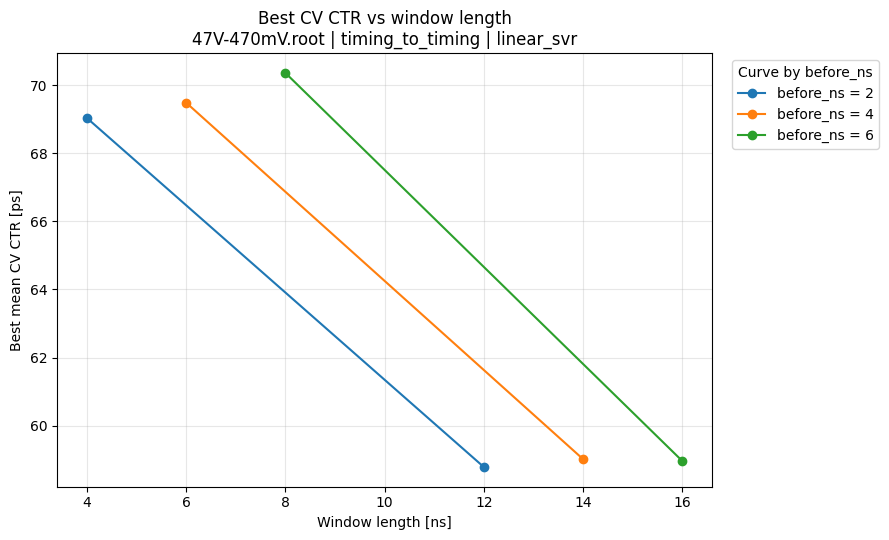

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from ml_pipeline.study import _read_results


# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------

STUDY_DIR = Path(
    "results/studies/folder_window_channel_3"
)

FILE_NAME = "47V-470mV.root"
CHANNEL_MODE = "timing_to_timing"
MODEL_ID = "linear_svr"


# ------------------------------------------------------------------
# Load and decode the exhaustive study results
# ------------------------------------------------------------------
# all_results.csv is numeric-coded; _read_results() decodes it using
# _state/results_metadata.json.
# ------------------------------------------------------------------

results_path = STUDY_DIR / "_state" / "all_results.csv"

rows = _read_results(results_path)
df = pd.DataFrame(rows)

if df.empty:
    raise ValueError(f"No results found in {results_path}")


# Convert relevant columns to numeric
numeric_columns = [
    "window_start_ns",
    "window_end_ns",
    "ctr_ps",
    "is_selected_hyperparameters",
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")


# Recover the original ROOT filename from its stored path
df["file_name"] = df["root_file"].apply(
    lambda value: Path(str(value)).name
)


# ------------------------------------------------------------------
# Keep one mean validation result per completed hyperparameter-selected
# model/loss/transform/window block
# ------------------------------------------------------------------

filtered = df[
    (df["record_type"] == "summary")
    & (df["split"] == "validation")
    & (df["statistic"] == "mean")
    & (df["status"] == "completed")
    & (df["is_selected_hyperparameters"] == 1)
    & (df["file_name"] == FILE_NAME)
    & (df["channel_mode"] == CHANNEL_MODE)
    & (df["model_id"] == MODEL_ID)
].copy()

if filtered.empty:
    available = (
        df[
            (df["record_type"] == "summary")
            & (df["split"] == "validation")
            & (df["statistic"] == "mean")
        ][["file_name", "channel_mode", "model_id"]]
        .drop_duplicates()
        .sort_values(["file_name", "channel_mode", "model_id"])
    )

    display(available)

    raise ValueError(
        "No matching results found. "
        "The available file/channel/model combinations are shown above."
    )


# ------------------------------------------------------------------
# For each window, select the best result obtained by this model.
#
# This minimizes mean CV CTR over:
#   - loss function
#   - input transform
#
# Hyperparameters have already been selected by CV inside each block.
# ------------------------------------------------------------------

window_keys = [
    "window_start_ns",
    "window_end_ns",
]

best_indices = (
    filtered
    .groupby(window_keys, dropna=False)["ctr_ps"]
    .idxmin()
)

best_by_window = (
    filtered.loc[best_indices]
    .copy()
    .sort_values(window_keys)
    .reset_index(drop=True)
)


# Convert the current [start, end] convention into the old
# before_ns / after_ns convention.
best_by_window["before_ns"] = -best_by_window["window_start_ns"]
best_by_window["after_ns"] = best_by_window["window_end_ns"]

best_by_window["window_length_ns"] = (
    best_by_window["window_end_ns"]
    - best_by_window["window_start_ns"]
)

best_by_window = best_by_window.rename(
    columns={"ctr_ps": "mean_validation_ctr_ps"}
)


# ------------------------------------------------------------------
# Display which loss and transform produced every plotted point
# ------------------------------------------------------------------

display_columns = [
    "window_id",
    "window_start_ns",
    "window_end_ns",
    "before_ns",
    "after_ns",
    "window_length_ns",
    "mean_validation_ctr_ps",
    "loss_id",
    "input_transform",
    "trial_id",
]

display(
    best_by_window[display_columns]
    .sort_values(["before_ns", "window_length_ns"])
    .round(3)
)


# ------------------------------------------------------------------
# Plot: best mean CV CTR versus window length, grouped by before_ns
# ------------------------------------------------------------------

plt.figure(figsize=(9, 5.5))

for before_ns, group in sorted(
    best_by_window.groupby("before_ns"),
    key=lambda item: item[0],
):
    group = group.sort_values("window_length_ns")

    plt.plot(
        group["window_length_ns"],
        group["mean_validation_ctr_ps"],
        marker="o",
        linewidth=1.5,
        label=f"before_ns = {before_ns:g}",
    )

plt.xlabel("Window length [ns]")
plt.ylabel("Best mean CV CTR [ps]")

plt.title(
    f"Best CV CTR vs window length\n"
    f"{FILE_NAME} | {CHANNEL_MODE} | {MODEL_ID}"
)

plt.legend(
    title="Curve by before_ns",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()